# Detección de pertenencias olvidadas en aulas con YOLO26

**Aplicación:** sistema de visión por computadora que revisa el video de una cámara fija de un aula y muestra
**solo** las pertenencias que los estudiantes pueden olvidar: laptops, celulares y mochilas.

Para esta actividad se usa el modelo preentrenado **YOLO26** (versión mediana, entrenada con las 80 clases del
dataset COCO) y se modifica el **post-procesamiento** para que únicamente se muestren las clases activadas.
Todo se ejecuta de forma local.

## 1. Aplicación y problema que resuelve

**Problema.** Al terminar una clase, los estudiantes suelen dejar laptops, celulares y mochilas en las aulas y
laboratorios. Revisar el aula a ojo es lento y se pasan cosas por alto, sobre todo cuando hay muchas mesas.

**Solución.** Una cámara fija analiza el video con YOLO y lleva la cuenta de las pertenencias que hay en el aula:

- Dibuja una caja con su nombre sobre cada laptop, celular y mochila.
- Muestra un contador por clase y un aviso con el total de pertenencias.

**¿Por qué filtrar clases?** En un aula también hay personas, sillas, mesas, botellas y monitores. Para este problema
esos objetos no importan, y mostrarlos llenaría la imagen de cajas inútiles y haría imposible ver lo importante.
Por eso el sistema **ignora** todo lo que no sea una pertenencia olvidable.

**Video de prueba.** Aula vista desde una cámara alta y fija (10 s, 1280 x 720, 24 fps) con estudiantes que trabajan
con sus laptops y luego salen, dejando cosas sobre las mesas. El video fue **generado con IA (Gemini)**.

## 2. Clases activadas y desactivadas

| Estado | Clases |
|---|---|
| **Activadas (3)** | `laptop`, `cell phone`, `backpack` |
| **Desactivadas (ejemplos presentes en el video)** | `person`, `chair`, `bottle`, `dining table`, `book` y el resto de clases de COCO |

Las clases desactivadas **sí aparecen en el video**, y YOLO las detecta. Es el sistema el que decide no mostrarlas.

**Nota sobre las etiquetas.** YOLO usa solo las 80 clases del dataset COCO, y COCO no tiene una clase para
"computadora de escritorio". Su clase `tv` incluye los televisores y también los **monitores de computadora**, por
eso el monitor de computadora que hay al fondo del aula aparece como `tv` en las imágenes sin filtro. Es una clase ignorada y no
afecta al sistema.

## 3. Configuración

In [1]:
import collections
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO

In [2]:
# Rutas del proyecto (este notebook vive en la carpeta notebooks/)
VIDEO_PATH = Path('../data/videos/aula.mp4')
REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(exist_ok=True)

# Modelo preentrenado YOLO26 mediano (m). Si el archivo no está en la raíz del proyecto, Ultralytics lo descarga.
MODEL_PATH = Path('../yolo26m.pt')
model = YOLO(str(MODEL_PATH) if MODEL_PATH.exists() else 'yolo26m.pt')

# CLASES ACTIVADAS: solo estas se muestran. Todo lo demás se ignora.
ACTIVE_CLASSES = ['laptop', 'cell phone', 'backpack']

# Color de cada clase activada (formato BGR, el de OpenCV)
CLASS_COLORS = {
    'laptop': (0, 255, 0),         # verde
    'cell phone': (0, 255, 255),   # amarillo
    'backpack': (255, 0, 255),     # magenta
}

# Resolución de análisis. Por defecto YOLO reduce la imagen a 640 px, y los objetos pequeños o tapados se pierden.
# Se combinan varias pasadas:
#   - IMGSZ: pasada principal con todas las clases, a 1280 px
#   - EXTRA_PASSES: pasadas extra, cada una solo para ciertas clases. Los celulares (muy pequeños) tienen una
#     pasada a 960 px y las mochilas parcialmente tapadas por una persona o una silla, una pasada a 1600 px.
IMGSZ = 1280
EXTRA_PASSES = {960: ['cell phone'], 1600: ['backpack']}

# Umbral de confianza propio de cada clase activada. El celular es pequeño y la mochila suele estar tapada, y YOLO
# les da puntajes más bajos, por eso sus umbrales son menores. Lo que queda por debajo del umbral de su clase se descarta.
CLASS_CONF = {'laptop': 0.25, 'cell phone': 0.20, 'backpack': 0.18}

# Área mínima de la caja, en píxeles. Descarta cajas demasiado pequeñas para ser de esa clase, por ejemplo un
# estuche que el modelo a veces confunde con una mochila.
MIN_AREA = {'backpack': 3000}

# Zonas excluidas, en píxeles (x1, y1, x2, y2). La cámara es fija, así que se puede ignorar una zona donde hay un
# equipo permanente del aula que no es una pertenencia. Aquí: el monitor de computadora del escritorio del fondo,
# que el modelo a veces confunde con una laptop.
EXCLUDED_ZONES = [(580, 45, 635, 118)]

# Umbral mínimo con el que se ejecuta el detector (el menor de los umbrales por clase)
CONF_FLOOR = min(CLASS_CONF.values())

# El modelo trabaja con ids numéricos, así que convertimos nombre de clase -> id
name_to_id = {name: idx for idx, name in model.names.items()}
ACTIVE_IDS = {name_to_id[name] for name in ACTIVE_CLASSES}

print(f'El modelo reconoce {len(model.names)} clases en total')
for name in ACTIVE_CLASSES:
    print(f'  ACTIVADA: {name} (id {name_to_id[name]})')

El modelo reconoce 80 clases en total
  ACTIVADA: laptop (id 63)
  ACTIVADA: cell phone (id 67)
  ACTIVADA: backpack (id 24)


## 4. Lógica de la aplicación: filtro por post-procesamiento

El modelo analiza cada cuadro y devuelve **todas** las cajas que encuentra, de las 80 clases. El filtro se aplica
después, sobre ese resultado:

1. `split_detections` separa las cajas en **activas** (clases elegidas, que además superen el umbral de su clase) e
   **ignoradas** (todas las demás).
2. `draw_active` dibuja **solo** las activas. Las ignoradas nunca se dibujan.
3. `draw_panel` agrega el contador por clase y el aviso con el total de pertenencias.

Los celulares son objetos muy pequeños y algunas mochilas están tapadas, así que `detect_all` analiza cada cuadro en
**tres pasadas**: una a 1280 px con todas las clases, otra a 960 px solo para celulares y otra a 1600 px solo para
mochilas, que recuperan lo que la primera no detecta. Luego une los resultados sin repetir cajas (`merge_extra`). La función `accept` descarta las cajas que no superan el umbral de su
clase, que son demasiado pequeñas para ser una mochila o que caen en una zona excluida (el monitor fijo del
escritorio del fondo, que el modelo confunde con una laptop).

Ultralytics también permite filtrar con `model(frame, classes=[...])`. Más abajo se comprueba que ese filtro
nativo da el mismo resultado que este post-procesamiento.

In [3]:
def accept(name, conf, box):
    """Acepta una detección activada si supera el umbral de su clase, no es demasiado pequeña y no está en una
    zona excluida."""
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2                      # centro de la caja
    in_excluded = any(zx1 <= cx <= zx2 and zy1 <= cy <= zy2 for zx1, zy1, zx2, zy2 in EXCLUDED_ZONES)
    return (conf >= CLASS_CONF[name]
            and (x2 - x1) * (y2 - y1) >= MIN_AREA.get(name, 0)
            and not in_excluded)


def split_detections(result):
    """Separa las detecciones de un cuadro en activas e ignoradas.

    Es el post-procesamiento clave de la aplicación: el modelo detecta las 80 clases,
    pero aquí decidimos cuáles se conservan.

    Devuelve dos listas de tuplas (nombre_clase, confianza, (x1, y1, x2, y2)).
    """
    active, ignored = [], []
    for box in result.boxes:
        cls_id = int(box.cls[0])                                   # id numérico de la clase
        conf = float(box.conf[0])                                  # confianza entre 0 y 1
        x1, y1, x2, y2 = (int(v) for v in box.xyxy[0].tolist())    # esquinas de la caja
        name = model.names[cls_id]
        detection = (name, conf, (x1, y1, x2, y2))
        if cls_id in ACTIVE_IDS:
            # Una clase activada solo se acepta si pasa el umbral y el tamaño mínimo de su clase
            if accept(name, conf, (x1, y1, x2, y2)):
                active.append(detection)
        else:
            # Las clases desactivadas se ignoran: nunca llegan a la lista de activas
            ignored.append(detection)
    return active, ignored


def iou(a, b):
    """Intersección sobre unión de dos cajas (x1, y1, x2, y2): mide cuánto se solapan."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter + 1e-9)


def merge_extra(active, extra, iou_thr=0.3):
    """Agrega a `active` las detecciones de la pasada extra que no repiten un objeto ya detectado."""
    merged = list(active)
    for name, conf, box in sorted(extra, key=lambda d: d[1], reverse=True):
        repeated = any(n == name and iou(box, b) >= iou_thr for n, _, b in merged)
        if not repeated:
            merged.append((name, conf, box))
    return merged


def detect_all(frame):
    """Detecta en varias escalas y devuelve (resultado sin filtro, detecciones activas, detecciones ignoradas)."""
    # Pasada principal: las 80 clases a resolución IMGSZ
    result = model(frame, imgsz=IMGSZ, conf=CONF_FLOOR, verbose=False)[0]
    active, ignored = split_detections(result)

    # Pasadas extra: cada una a otra resolución y solo para las clases que se detectan mejor a esa escala
    for size, names in EXTRA_PASSES.items():
        extra_result = model(frame, imgsz=size, conf=CONF_FLOOR,
                             classes=[name_to_id[n] for n in names], verbose=False)[0]
        extra, _ = split_detections(extra_result)
        # Se unen los resultados sin repetir los objetos que ya se habían detectado
        active = merge_extra(active, extra)

    return result, active, ignored


def draw_active(frame, active):
    """Dibuja SOLO las detecciones de clases activadas (caja y etiqueta)."""
    out = frame.copy()                                             # no modificamos el cuadro original
    for name, conf, (x1, y1, x2, y2) in active:
        color = CLASS_COLORS[name]
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 3)           # caja de la detección
        label = f'{name} {conf:.2f}'
        (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(out, (x1, y1 - h - 10), (x1 + w + 6, y1), color, -1)   # franja detrás del texto
        cv2.putText(out, label, (x1 + 3, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0, 0, 0), 2, cv2.LINE_AA)
    return out


def draw_panel(frame, active):
    """Agrega el contador por clase y el aviso con el total de pertenencias."""
    counts = collections.Counter(name for name, _, _ in active)
    total = sum(counts.values())

    # Panel con el contador por clase
    cv2.rectangle(frame, (10, 10), (330, 45 + 30 * len(ACTIVE_CLASSES)), (30, 30, 30), -1)
    cv2.putText(frame, 'Pertenencias detectadas', (20, 33), cv2.FONT_HERSHEY_SIMPLEX,
                0.6, (255, 255, 255), 2, cv2.LINE_AA)
    for i, name in enumerate(ACTIVE_CLASSES):
        cv2.putText(frame, f'{name}: {counts[name]}', (20, 66 + 30 * i),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, CLASS_COLORS[name], 2, cv2.LINE_AA)

    # Banda roja inferior con el total, solo si hay al menos una pertenencia en el aula
    if total > 0:
        h, w = frame.shape[:2]
        cv2.rectangle(frame, (0, h - 40), (w, h), (0, 0, 200), -1)
        cv2.putText(frame, f'Pertenencias en el aula: {total}', (15, h - 12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    return frame

## 5. Ejecución sobre el video

Se procesa el video cuadro por cuadro y se generan dos salidas en la carpeta `reports/`:

- `aula_filtrado.mp4`: el resultado del sistema, con solo las clases activadas.
- `aula_comparacion.mp4`: a un lado YOLO sin filtro (80 clases) y al otro el sistema filtrado.

Además se guardan cuatro momentos clave para la evidencia y se cuenta en cuántos cuadros YOLO ve cada clase.

In [4]:
# Momentos del video (en segundos) que se usarán como evidencia
KEY_SECONDS = [0, 6, 8, 9.8]

cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Video: {width}x{height}, {fps:.0f} fps, {total_frames} cuadros, {total_frames / fps:.1f} s')

# Índice de cuadro correspondiente a cada momento clave
key_index = {min(int(s * fps), total_frames - 1): s for s in KEY_SECONDS}

# Escritores de video (códec mp4v): uno para el resultado y otro para la comparación
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_filtered = cv2.VideoWriter(str(REPORTS_DIR / 'aula_filtrado.mp4'), fourcc, fps, (width, height))
out_compare = cv2.VideoWriter(str(REPORTS_DIR / 'aula_comparacion.mp4'), fourcc, fps, (width * 2, height))

frames_seen = collections.Counter()   # en cuántos cuadros YOLO detecta cada clase (sin filtro)
drawn_classes = set()                 # clases que el sistema realmente dibujó
key_images = {}                       # cuadros clave: (sin filtro, filtrado)

frame_idx = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    # 1) YOLO detecta en el cuadro (dos escalas) y 2) el post-procesamiento deja solo las clases activadas
    result, active, ignored = detect_all(frame)

    # 3) Estadísticas para la evidencia
    for name in {n for n, _, _ in active + ignored}:
        frames_seen[name] += 1
    drawn_classes.update(n for n, _, _ in active)

    # 4) Imagen del sistema (filtrada) e imagen de comparación (YOLO sin filtro)
    filtered = draw_panel(draw_active(frame, active), active)
    raw = result.plot()                                           # dibuja todas las clases detectadas
    cv2.putText(raw, 'YOLO sin filtro (80 clases)', (15, height - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)

    out_filtered.write(filtered)
    out_compare.write(np.hstack([raw, filtered]))
    if frame_idx in key_index:
        key_images[key_index[frame_idx]] = (raw.copy(), filtered.copy())
    frame_idx += 1

cap.release()
out_filtered.release()
out_compare.release()

print(f'Cuadros procesados: {frame_idx}')
print(f'Clases dibujadas por el sistema: {sorted(drawn_classes)}')
# Comprobación automática: el sistema nunca dibujó una clase desactivada
assert drawn_classes <= set(ACTIVE_CLASSES), 'Se dibujó una clase que debía estar ignorada'
print('Comprobación superada: solo se dibujaron clases activadas')

Video: 1280x720, 24 fps, 240 cuadros, 10.0 s


Cuadros procesados: 240
Clases dibujadas por el sistema: ['backpack', 'cell phone', 'laptop']
Comprobación superada: solo se dibujaron clases activadas


## 6. Evidencia: objetos detectados y objetos ignorados

En cada figura, la imagen de **arriba** es YOLO sin filtro (todas las clases) y la de **abajo** es el sistema final.
Arriba se ven cajas de `person`, `chair`, `bottle`, `dining table` y otras, que son objetos presentes en el
aula pero **desactivados**. Abajo solo quedan las laptops, los celulares y las mochilas.
En todos los momentos hay al menos dos pertenencias detectadas a la vez.

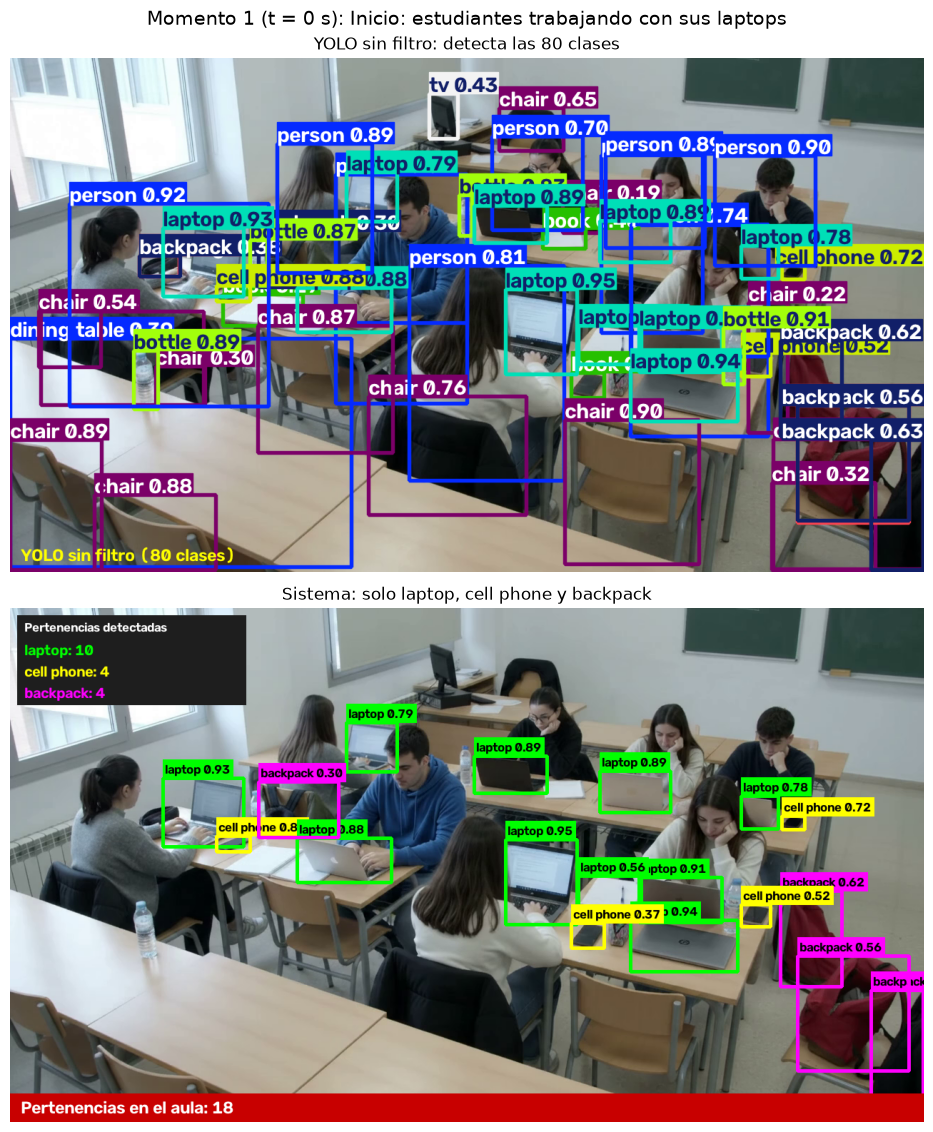

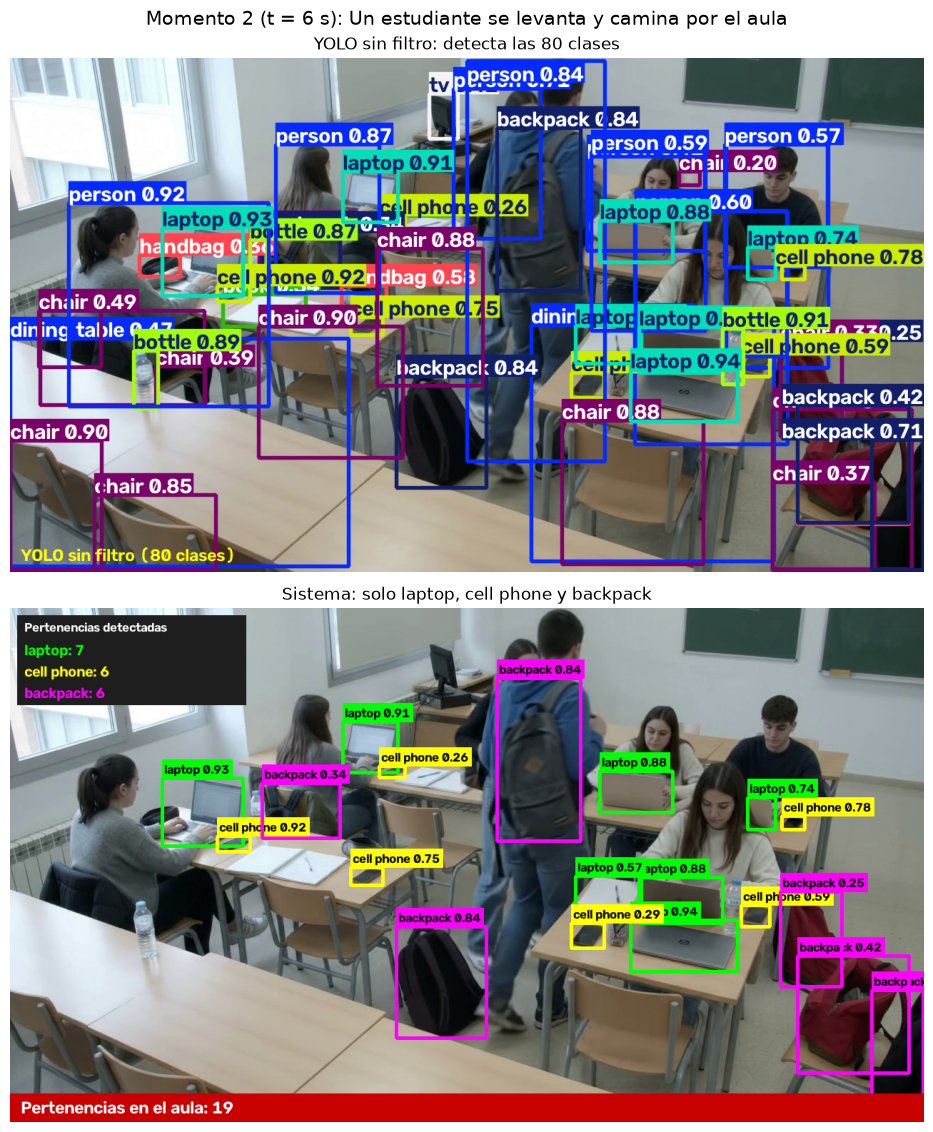

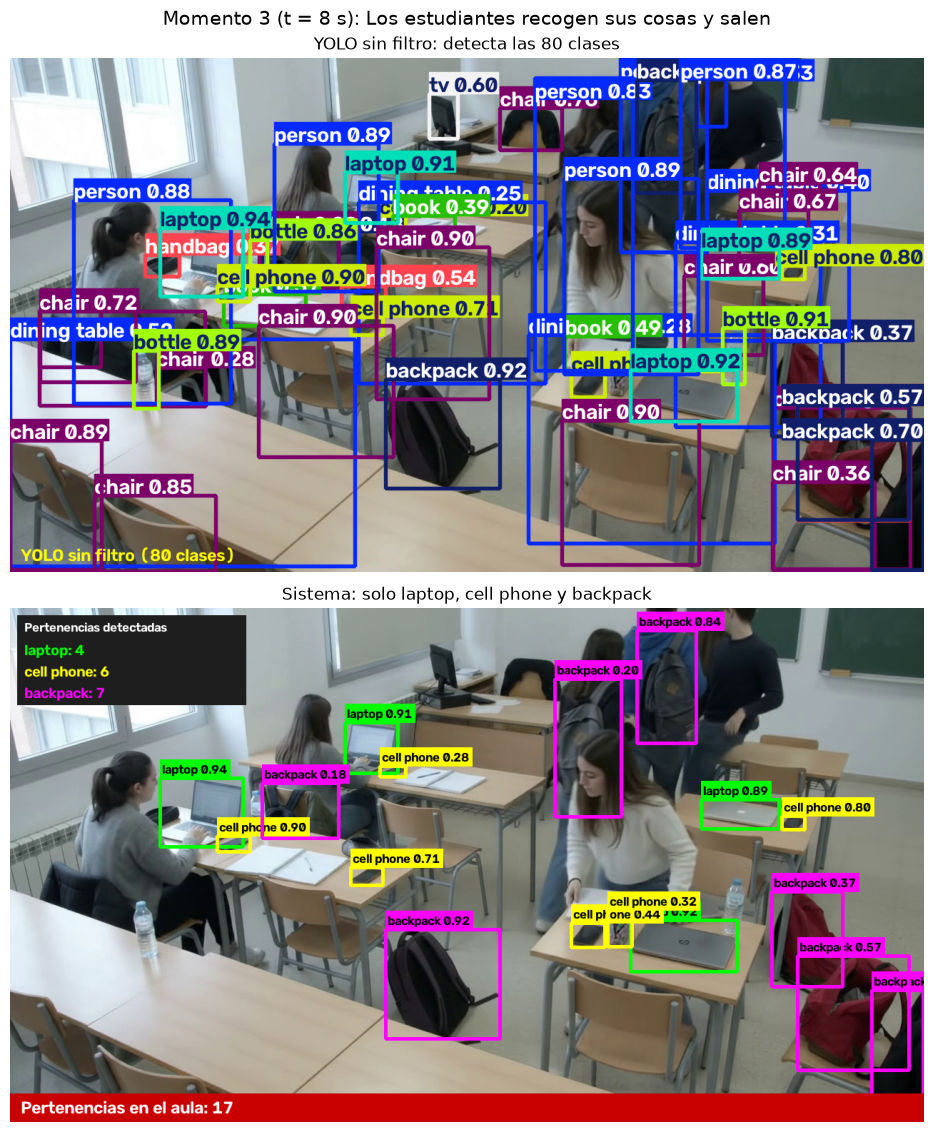

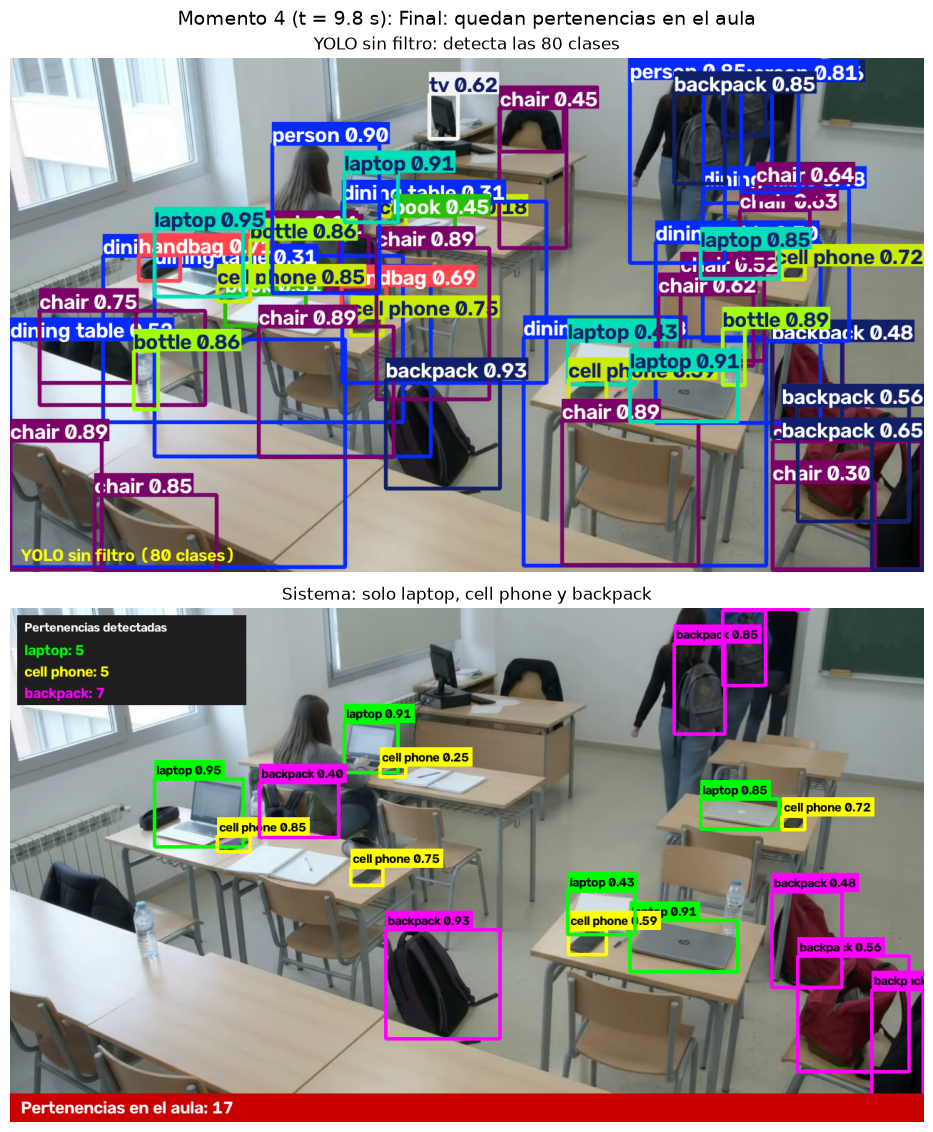

In [5]:
MOMENTS = {
    0: 'Inicio: estudiantes trabajando con sus laptops',
    6: 'Un estudiante se levanta y camina por el aula',
    8: 'Los estudiantes recogen sus cosas y salen',
    9.8: 'Final: quedan pertenencias en el aula',
}

for n, (second, title) in enumerate(MOMENTS.items(), start=1):
    raw_img, filtered_img = key_images[second]
    # Dos filas (una sobre otra) para que cada imagen ocupe todo el ancho de la hoja en el PDF
    fig, axes = plt.subplots(2, 1, figsize=(10, 11.5))
    # OpenCV usa BGR y Matplotlib RGB, por eso se convierte antes de mostrar
    axes[0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('YOLO sin filtro: detecta las 80 clases')
    axes[1].imshow(cv2.cvtColor(filtered_img, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Sistema: solo laptop, cell phone y backpack')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(f'Momento {n} (t = {second} s): {title}', fontsize=14)
    plt.tight_layout()
    fig.savefig(REPORTS_DIR / f'evidencia_{n}.png', dpi=100)   # copia para el informe
    plt.show()

## 7. Resumen: qué se detecta y qué se ignora

La tabla y la gráfica cuentan en cuántos cuadros del video YOLO detecta cada clase, y si el sistema la muestra.

Clase         Cuadros donde YOLO la detecta   ¿La muestra el sistema?
book          240                             NO (ignorada)
cell phone    240                             SI (activada)
person        240                             NO (ignorada)
backpack      240                             SI (activada)
chair         240                             NO (ignorada)
laptop        240                             SI (activada)
dining table  240                             NO (ignorada)
handbag       240                             NO (ignorada)
bottle        240                             NO (ignorada)
tv            230                             NO (ignorada)


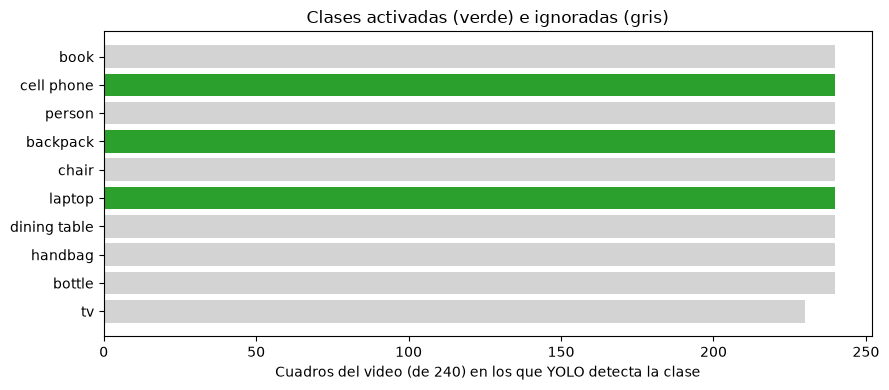

In [6]:
print(f"{'Clase':<14}{'Cuadros donde YOLO la detecta':<32}{'¿La muestra el sistema?'}")
for name, n in frames_seen.most_common():
    shown = 'SI (activada)' if name in ACTIVE_CLASSES else 'NO (ignorada)'
    print(f'{name:<14}{n:<32}{shown}')

# Gráfica: clases activadas en color y clases ignoradas en gris
names = [n for n, _ in frames_seen.most_common()][::-1]
values = [frames_seen[n] for n in names]
colors = ['tab:green' if n in ACTIVE_CLASSES else 'lightgray' for n in names]

plt.figure(figsize=(9, 4))
plt.barh(names, values, color=colors)
plt.xlabel(f'Cuadros del video (de {total_frames}) en los que YOLO detecta la clase')
plt.title('Clases activadas (verde) e ignoradas (gris)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'resumen_clases.png', dpi=100)
plt.show()

## 8. Verificación del filtro

Se compara el post-procesamiento propio con el filtro nativo de YOLO (`classes=[...]`) sobre un mismo cuadro.
Si los dos dan las mismas cajas, el filtro está bien implementado.

In [7]:
# Tomamos un cuadro del medio del video
cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, 72)
ok, test_frame = cap.read()
cap.release()

# Filtro nativo de YOLO: el modelo solo busca las clases indicadas (y luego aplicamos el umbral de cada clase)
native = model(test_frame, imgsz=IMGSZ, conf=CONF_FLOOR, classes=sorted(ACTIVE_IDS), verbose=False)[0]
native_counts = collections.Counter(
    model.names[int(c)] for c, p, xy in zip(native.boxes.cls, native.boxes.conf, native.boxes.xyxy.tolist())
    if accept(model.names[int(c)], float(p), tuple(int(v) for v in xy))
)

# Nuestro post-procesamiento: detecta todo y luego filtra
all_result = model(test_frame, imgsz=IMGSZ, conf=CONF_FLOOR, verbose=False)[0]
active_test, ignored_test = split_detections(all_result)
own_counts = collections.Counter(n for n, _, _ in active_test)

print('Filtro nativo (classes=[...]):', dict(native_counts))
print('Post-procesamiento propio    :', dict(own_counts))
print('Objetos ignorados en este cuadro:', dict(collections.Counter(n for n, _, _ in ignored_test)))
assert native_counts == own_counts, 'Los dos filtros no coinciden'
print('Los dos filtros dan el mismo resultado')

Filtro nativo (classes=[...]): {'laptop': 10, 'cell phone': 3, 'backpack': 4}
Post-procesamiento propio    : {'laptop': 10, 'cell phone': 3, 'backpack': 4}
Objetos ignorados en este cuadro: {'person': 9, 'bottle': 4, 'chair': 17, 'handbag': 3, 'tv': 2, 'book': 3, 'dining table': 1}
Los dos filtros dan el mismo resultado


## 9. Conclusiones

- El sistema **detecta correctamente** laptops, mochilas y celulares y muestra un contador por clase, con al menos
  dos clases activas a la vez durante todo el video.
- Las clases **desactivadas** (`person`, `chair`, `bottle`, `dining table`, `book`) están presentes en el aula y YOLO
  las detecta, pero el sistema no las dibuja. La comprobación automática del paso 5 y la verificación del paso 8
  lo confirman.
- Filtrar clases deja una imagen limpia en la que se ve de inmediato qué pertenencias hay en el aula.

**Optimizaciones aplicadas.**

- **Modelo mediano.** Se usa YOLO26 en su versión mediana (`m`), que distingue mucho mejor los objetos pequeños y
  oscuros, como los celulares sobre las mesas y la mochila negra que queda en el piso.
- **Análisis en varias escalas.** Con la resolución por defecto (640 px) los celulares, que son muy pequeños en este
  video, y las mochilas parcialmente tapadas se perdían con facilidad. Se hace una pasada principal a 1280 px, otra
  a 960 px solo para celulares y otra a 1600 px solo para mochilas, y se unen los resultados sin repetir cajas.
- **Umbral de confianza por clase.** El celular usa 0.20, la mochila 0.18 y la laptop 0.25, para detectar los
  objetos pequeños o tapados sin aumentar los errores en el resto.
- **Tamaño mínimo para mochilas.** Se descartan las cajas de mochila demasiado pequeñas, que corresponden a objetos
  como un estuche.
- **Zona excluida.** Como la cámara es fija, se ignora la zona del monitor de computadora del escritorio del fondo,
  un equipo permanente del aula que el modelo a veces confunde con una laptop.

**Mejoras futuras.**

- **Modelos más grandes.** Probar las versiones `l` o `x` de YOLO26, que detectan mejor los objetos pequeños o
  parcialmente tapados, a costa de más tiempo de cómputo.
- **Entrenamiento con imágenes propias.** Ajustar el modelo con fotos de aulas y laboratorios reales, por ejemplo con
  Roboflow, para reconocer mejor los objetos tapados.
- **Seguimiento de objetos.** Identificar cuáles pertenencias llevan tiempo sin que nadie se acerque a ellas.
- **Alertas automáticas.** Enviar un aviso al personal del laboratorio con la ubicación y una imagen de las
  pertenencias olvidadas.
- **Más cámaras.** Cubrir toda el aula combinando varios puntos de vista.